<a href="https://colab.research.google.com/github/puki1291-debug/Network-Analysis-Practice-Sanctions/blob/main/Practice_1_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

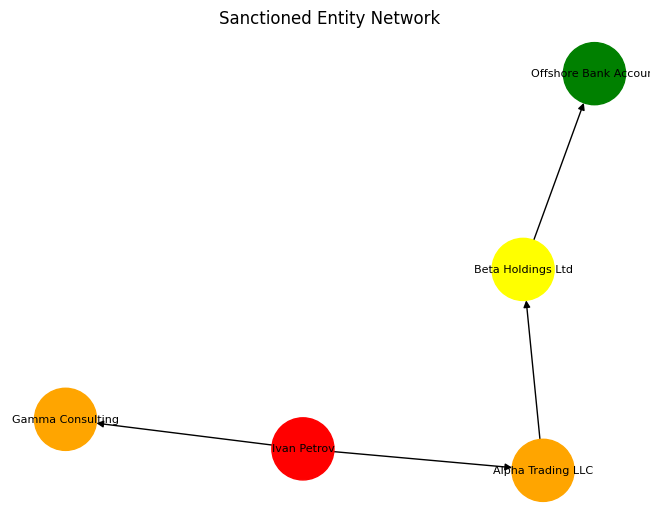

Most connected entity: Ivan Petrov
Path from Ivan to the account: ['Ivan Petrov', 'Alpha Trading LLC', 'Beta Holdings Ltd', 'Offshore Bank Account']


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Step 2: build a tiny graph by hand
G = nx.DiGraph()  # directed - ownership/control flows one way

# Add entities (nodes)
G.add_node("Ivan Petrov", type="sanctioned_person")
G.add_node("Alpha Trading LLC", type="front_company")
G.add_node("Beta Holdings Ltd", type="shell_company")
G.add_node("Gamma Consulting", type="front_company")
G.add_node("Offshore Bank Account", type="account")

# Add relationships (edges)
G.add_edge("Ivan Petrov", "Alpha Trading LLC", relationship="owns")
G.add_edge("Alpha Trading LLC", "Beta Holdings Ltd", relationship="subsidiary_of")
G.add_edge("Ivan Petrov", "Gamma Consulting", relationship="director_of")
G.add_edge("Beta Holdings Ltd", "Offshore Bank Account", relationship="controls")

# Step 3: draw it
colors = {"sanctioned_person": "red", "front_company": "orange",
          "shell_company": "yellow", "account": "green"}
node_colors = [colors[G.nodes[n]["type"]] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=node_colors,
        node_size=2000, font_size=8, arrows=True)
plt.title("Sanctioned Entity Network")
plt.show()

# Step 4: simple analysis
print("Most connected entity:", max(nx.degree_centrality(G), key=nx.degree_centrality(G).get))
print("Path from Ivan to the account:",
      nx.shortest_path(G, "Ivan Petrov", "Offshore Bank Account"))